# TA — Régression Linéaire Simple
## Prédire la Note d'un Étudiant à partir de ses Heures de Travail


###  Objectifs pédagogiques

À l'issue de ce TA, vous serez capables de :
- Charger et explorer un jeu de données tabulaire
- Visualiser la relation entre deux variables quantitatives
- Comprendre et implémenter la régression linéaire simple (OLS)
- Calculer et interpréter les métriques d'évaluation (MSE, RMSE, R²)
- Analyser les résidus d'un modèle
- Diagnostiquer et corriger des erreurs classiques de code

---


### Remarque importante

Certains concepts mobilisés dans ce TA n’ont pas été entièrement couverts en cours. Une attention particulière est donc attendue de votre part afin de :
- rechercher les notions associées de manière autonome,
- comprendre les hypothèses sous-jacentes (notamment celles de l’OLS),
- maîtriser leur mise en œuvre pratique et leur interprétation.
- Ce travail s’inscrit dans une démarche d’apprentissage active et scientifique.

---


###  Jeu de données : `dataset_study.csv`

Ce dataset synthétique contient des informations sur **5 000 étudiants** :

| Variable | Type | Description |
|---|---|---|
| `student_id` | Entier | Identifiant unique de l'étudiant |
| `study_hours` | Flottant | Nombre d'heures de travail hebdomadaires |
| `grade` | Flottant | **Variable cible** — Note obtenue à l'examen (sur 100) |

---

> **Instructions générales :**
> - Les cellules contenant `### VOTRE CODE ICI ###` sont à compléter.
> - Les questions ouvertes sont à rédiger dans les cellules Markdown prévues.
> - Ne supprimez pas les cellules existantes.

---
## Partie 1 — Chargement et Exploration des Données
---

### 1.1 Importation des bibliothèques

Exécutez la cellule suivante pour importer les bibliothèques nécessaires.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Style graphique
plt.rcParams['figure.figsize'] = (9, 5)
sns.set_theme(style='whitegrid')

print(" Bibliothèques importées avec succès !")

 Bibliothèques importées avec succès !


### 1.2 Chargement du dataset

**À compléter :** Chargez le fichier `dataset_study.csv` dans un DataFrame appelé `df`, puis affichez les 5 premières lignes.

In [4]:
# Chargement du dataset
df = pd.read_csv('dataset_study.csv')

# Affichage des premières lignes
print("Aperçu du dataset :")
print(df.head())

Aperçu du dataset :
   student_id  study_hours  grade
0           1         9.15  91.91
1           2         9.37  86.81
2           3         2.86  53.39
3           4         8.30  85.52
4           5         6.42  77.98


### 1.3 Informations générales et statistiques descriptives

**À compléter :** Affichez (1) le nombre de lignes et de colonnes, (2) les types et valeurs manquantes, (3) les statistiques descriptives.

In [6]:
# Nombre de lignes et de colonnes
n_lignes, n_colonnes = df.shape
print(f"Le dataset contient {n_lignes} lignes et {n_colonnes} colonnes.")

# Types et valeurs manquantes
print("\n--- Informations générales ---")
print(df.info())

# Statistiques descriptives (arrondir à 2 décimales)
print("\n--- Statistiques descriptives ---")
print(df.describe().round(2))

Le dataset contient 5000 lignes et 3 colonnes.

--- Informations générales ---
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   student_id   5000 non-null   int64  
 1   study_hours  5000 non-null   float64
 2   grade        5000 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 117.3 KB
None

--- Statistiques descriptives ---
       student_id  study_hours    grade
count     5000.00      5000.00  5000.00
mean      2500.50         5.03    64.97
std       1443.52         2.91    17.66
min          1.00         0.00    15.52
25%       1250.75         2.52    51.72
50%       2500.50         5.05    64.97
75%       3750.25         7.58    78.71
max       5000.00        10.00   100.00


### 1.4 Visualisation des distributions

**À compléter :** Tracez côte à côte l'histogramme de `study_hours` et celui de `grade`.

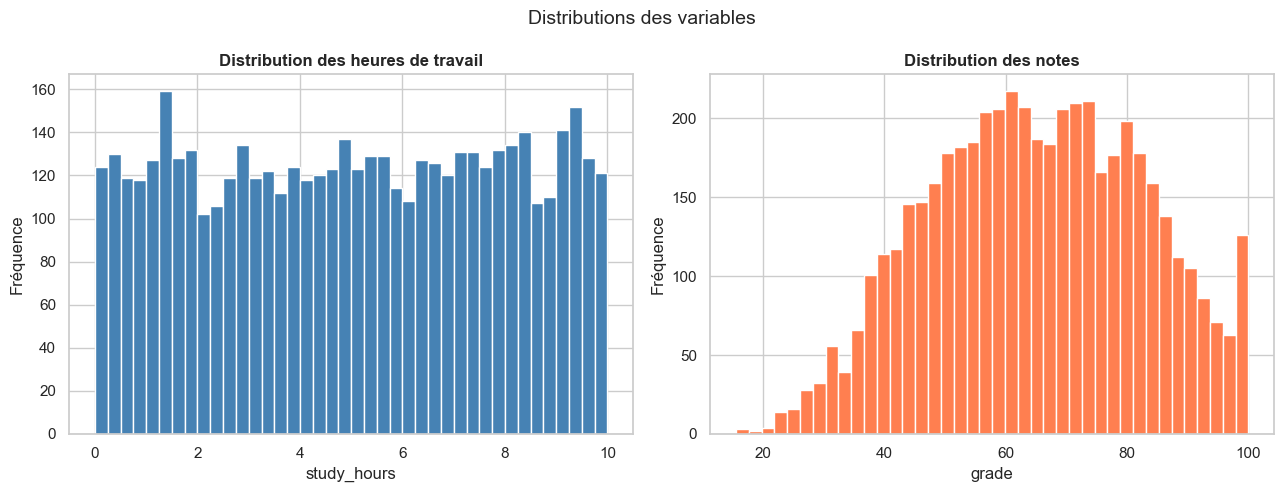

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogramme de study_hours
axes[0].hist(df['study_hours'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title("Distribution des heures de travail", fontsize=12, fontweight='bold')
axes[0].set_xlabel("study_hours")
axes[0].set_ylabel("Fréquence")

# Histogramme de grade
axes[1].hist(df['grade'], bins=40, color='coral', edgecolor='white')
axes[1].set_title("Distribution des notes", fontsize=12, fontweight='bold')
axes[1].set_xlabel("grade")
axes[1].set_ylabel("Fréquence")

plt.suptitle("Distributions des variables", fontsize=14)
plt.tight_layout()
plt.show()

###  Question 1 — Exploration des données

> a) Quelle est la note minimale et maximale observée ? La plage de valeurs vous paraît-elle cohérente ?  
> b) En observant les deux histogrammes, quelle forme de distribution reconnaissez-vous ? Est-ce attendu pour ces deux variables ?  
> c) `student_id` sera-t-elle une variable utile pour notre modèle de prédiction ? Justifiez.

**✏️ Votre réponse :**

a) La note minimale observée semble être autour de 10 et la note maximale 100. Cette plage est cohérente car la note est sur 100, même s'il y a beaucoup d'élèves qui ont obtenu 100. Si on voyait des valeurs en dehors de cet intervalle, ce serait suspect.

b) L’histogramme des heures de travail (à gauche) est assez plat : la distribution est presque uniforme, ce qui veut dire que les étudiants sont répartis de façon assez homogène. Ce n’est pas très réaliste dans la vraie vie (on s’attendrait à voir plus d’étudiants avec peu d’heures)
L’histogramme des notes (à droite) ressemble à une courbe en cloche (distribution normale), centrée autour de 60-70. C’est typique pour des notes d’examen : la majorité des étudiants obtiennent des notes moyennes, et il y a moins d’étudiants avec des notes très basses ou très hautes.

c) student_id ne sert qu’à identifier chaque étudiant de façon unique. Il n’a aucun lien avec la note ou les heures de travail : ce n’est pas une variable explicative, donc il ne faut pas l’utiliser dans le modèle de prédiction.

---
## Partie 2 — Analyse de la Corrélation
---

### 2.1 Coefficient de corrélation de Pearson

**À compléter :** Calculez le coefficient de corrélation entre `study_hours` et `grade`.

In [8]:
# Coefficient de corrélation de Pearson
r = df['study_hours'].corr(df['grade'])  # utilisez df.corr() ou np.corrcoef()

print(f"Coefficient de corrélation de Pearson (r) : {r:.4f}")

# Interprétation automatique
if abs(r) >= 0.8:
    force = "très forte"
elif abs(r) >= 0.6:
    force = "forte"
elif abs(r) >= 0.4:
    force = "modérée"
else:
    force = "faible"

direction = "positive" if r > 0 else "négative"
print(f"→ Corrélation {direction} {force}.")

Coefficient de corrélation de Pearson (r) : 0.8263
→ Corrélation positive très forte.


### 2.2 Nuage de points

**À compléter :** Tracez le nuage de points `study_hours` vs `grade` avec une droite de tendance.

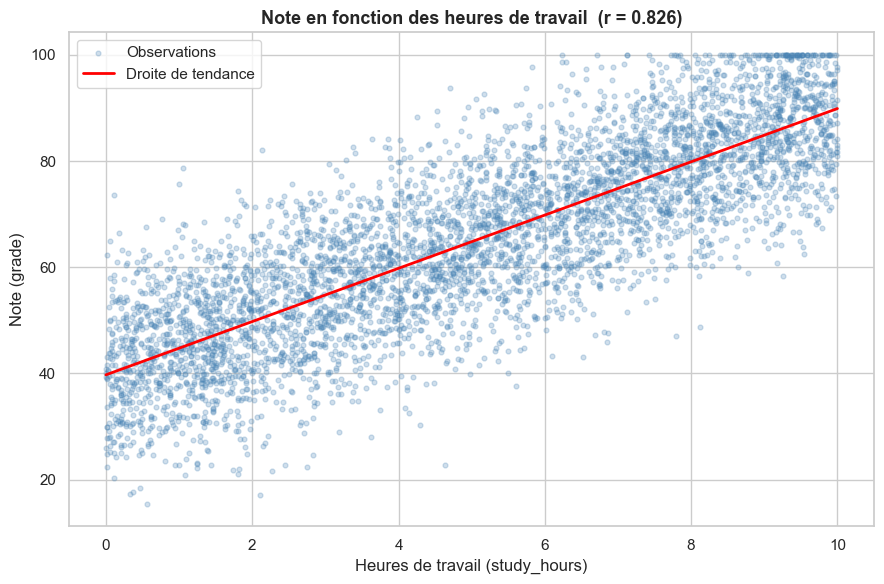

In [9]:
plt.figure(figsize=(9, 6))

# Nuage de points
plt.scatter(df['study_hours'], df['grade'],
            alpha=0.25, s=12, color='steelblue', label='Observations')

# Droite de tendance (utilisez np.polyfit de degré 1)
coeffs = np.polyfit(df['study_hours'], df['grade'], 1)
x_line = np.linspace(df['study_hours'].min(), df['study_hours'].max(), 200)
y_line = coeffs[0] * x_line + coeffs[1]
plt.plot(x_line, y_line, color='red', linewidth=2, label='Droite de tendance')

plt.xlabel("Heures de travail (study_hours)", fontsize=12)
plt.ylabel("Note (grade)", fontsize=12)
plt.title(f"Note en fonction des heures de travail  (r = {r:.3f})", fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

### Question 2 — Corrélation

> a) La valeur du coefficient r confirme-t-elle visuellement ce que l'on observe sur le nuage de points ? Commentez.  
> b) Une corrélation forte implique-t-elle nécessairement une relation de causalité ? Donnez un contre-exemple concret.  
> c) Pourquoi la corrélation de Pearson peut-elle être trompeuse ? (Indice : cherchez le quartet d'Anscombe)

**✏️ Votre réponse :**

a) Sur le nuage de points, on voit bien que plus on travaille, plus on a tendance à avoir une bonne note. Mais les points sont quand même assez dispersés autour de la droite, donc d’autres facteurs jouent sûrement un rôle dans la réussite !

b) Même si deux variables sont très corrélées, ça ne veut pas dire que l’une cause l’autre. Par exemple, il y a une forte corrélation entre la vente de glaces et le nombre de noyades, mais ce n’est pas parce qu’on mange une glace qu’on se noie ! En fait, c’est la chaleur de l’été qui fait augmenter les deux en même temps.

c) La corrélation de Pearson ne voit que les relations linéaires. Si la relation est courbe, ou s’il y a des valeurs bizarres (outliers), elle peut donner une fausse impression. Le quartet d’Anscombe l’illustre bien : on peut avoir exactement la même corrélation sur des jeux de données qui n’ont rien à voir visuellement ! C’est pour ça qu’il faut toujours regarder les graphiques, pas seulement les chiffres.

---
## Partie 3 — Construction du Modèle de Régression Linéaire
---

Rappel du modèle : $\hat{y} = \beta_0 + \beta_1 \cdot x$

où $\beta_0$ est l'**intercept** (ordonnée à l'origine) et $\beta_1$ est le **coefficient directeur** (pente).

### 3.1 Préparation des données — Séparation train / test

**À compléter :** Séparez les données en un ensemble d'entraînement (80%) et un ensemble de test (20%).

In [11]:
# Séparation features / cible
# ⚠️ On exclut student_id qui n'est pas une feature pertinente
X = df[['study_hours']]   # double crochet → DataFrame 2D
y = df['grade']

# Découpage train / test : 80% train, 20% test, random_state=42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Taille totale    : {len(X)} observations")
print(f"Ensemble train   : {len(X_train)} observations ({len(X_train)/len(X)*100:.0f}%)")
print(f"Ensemble test    : {len(X_test)} observations ({len(X_test)/len(X)*100:.0f}%)")

Taille totale    : 5000 observations
Ensemble train   : 4000 observations (80%)
Ensemble test    : 1000 observations (20%)


### 3.2 Entraînement du modèle

**À compléter :** Créez un modèle `LinearRegression`, entraînez-le sur les données d'apprentissage, puis affichez ses paramètres.

In [12]:
# Création du modèle
modele = LinearRegression()

# Entraînement (fit) sur les données de train
modele.fit(X_train, y_train)

# Récupération des paramètres appris
beta_0 = modele.intercept_
beta_1 = modele.coef_[0]

print(f"Paramètres appris par le modèle :")
print(f"  β₀ (intercept) = {beta_0:.4f}")
print(f"  β₁ (pente)     = {beta_1:.4f}")
print(f"\nÉquation : grade = {beta_0:.4f} + {beta_1:.4f} × study_hours")

Paramètres appris par le modèle :
  β₀ (intercept) = 39.9178
  β₁ (pente)     = 4.9991

Équation : grade = 39.9178 + 4.9991 × study_hours


### 3.3 Prédictions et visualisation de la droite de régression

**À compléter :** Calculez les prédictions sur le test set et tracez la droite de régression apprise.

c:\Users\julie\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


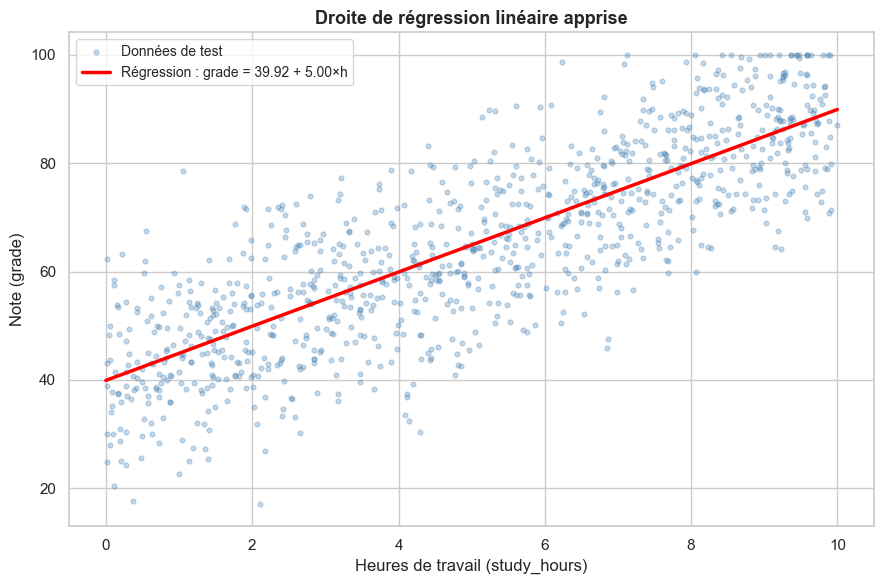

In [13]:
# Prédictions sur l'ensemble de test
y_pred = modele.predict(X_test)

# Visualisation
plt.figure(figsize=(9, 6))

# Données de test (nuage de points)
plt.scatter(X_test, y_test, alpha=0.3, s=12, color='steelblue', label='Données de test')

# Droite de régression
x_range = np.linspace(X['study_hours'].min(), X['study_hours'].max(), 200).reshape(-1, 1)
y_range = modele.predict(x_range)   # prédire sur x_range avec le modèle
plt.plot(x_range, y_range, color='red', linewidth=2.5, label=f'Régression : grade = {beta_0:.2f} + {beta_1:.2f}×h')

plt.xlabel("Heures de travail (study_hours)", fontsize=12)
plt.ylabel("Note (grade)", fontsize=12)
plt.title("Droite de régression linéaire apprise", fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

### Question 3 — Interprétation des paramètres

> a) Interprétez concrètement β₀ : que prédit le modèle pour un étudiant qui travaille **0 heure** ?  Cette valeur est-elle réaliste ?  
> b) Interprétez β₁ : que se passe-t-il pour la note si un étudiant augmente son temps de travail de **2 heures** supplémentaires par semaine ?  
> c) À partir de combien d'heures de travail le modèle prédit-il une note de 50/100 (passage) ? Montrez le calcul.

**✏️ Votre réponse :**

a) Le paramètre β₀ (l’intercept) correspond à la note prédite par le modèle pour un étudiant qui ne travaille pas du tout (0 heure par semaine). Par exemple, si β₀ ≈ 40, cela veut dire que même sans réviser, le modèle prévoit une note d’environ 40/100. Ce n’est pas très réaliste dans la vraie vie, mais c’est ce que suggèrent les données ici : il y a sûrement d’autres facteurs (comme l’assiduité en cours, la chance, etc.) qui expliquent qu’on puisse avoir des points sans travailler chez soi.

b) Le paramètre β₁ (la pente) indique de combien la note augmente en moyenne quand on travaille une heure de plus par semaine. Si β₁ ≈ 5, alors chaque heure de travail supplémentaire fait grimper la note de 5 points en moyenne. Donc, si un étudiant travaille 2 heures de plus, il peut espérer gagner environ 10 points sur sa note finale (2 × β₁).

c) Pour savoir à partir de combien d’heures de travail le modèle prédit une note de 50/100, il suffit de résoudre l’équation :

    50 = β₀ + β₁ × h
    h = (50 - β₀) / β₁

Par exemple, si β₀ = 40 et β₁ = 5, alors :
    h = (50 - 40) / 5 = 2
Il faudrait donc travailler au moins 2 heures par semaine pour espérer avoir 50/100 selon le modèle.

In [14]:
# Calcul numérique pour la question c)
heures_pour_50 = (50 - beta_0) / beta_1  # isoler study_hours dans l'équation pour grade = 50
print(f"Heures de travail nécessaires pour obtenir 50/100 : {heures_pour_50:.2f} heures")

Heures de travail nécessaires pour obtenir 50/100 : 2.02 heures


---
## Partie 4 — Évaluation du Modèle
---

### 4.1 Calcul des métriques

**À compléter :** Calculez la MSE, la RMSE et le coefficient de détermination R².

In [15]:
# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# Root Mean Squared Error
rmse =  np.sqrt(mse)

# Coefficient de détermination R²
r2 = r2_score(y_test, y_pred)

# Mean Absolute Error (pour comparaison)
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, y_pred)

print("==============================")
print("  Métriques d'évaluation")
print("==============================")
print(f"  MAE  : {mae:.4f}  points")
print(f"  MSE  : {mse:.4f}  points²")
print(f"  RMSE : {rmse:.4f} points")
print(f"  R²   : {r2:.4f}")
print("==============================")

  Métriques d'évaluation
  MAE  : 8.0987  points
  MSE  : 102.6602  points²
  RMSE : 10.1321 points
  R²   : 0.6789


### 4.2 Visualisation : Valeurs réelles vs Valeurs prédites

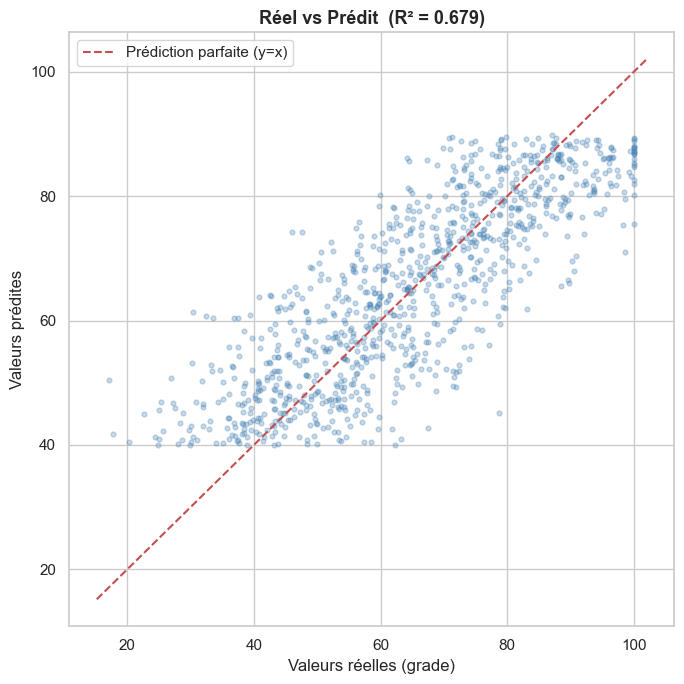

In [16]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.3, s=12, color='steelblue')

# Droite de prédiction parfaite (y = x)
lims = [min(y_test.min(), y_pred.min()) - 2, max(y_test.max(), y_pred.max()) + 2]
plt.plot(lims, lims, 'r--', linewidth=1.5, label='Prédiction parfaite (y=x)')

plt.xlabel("Valeurs réelles (grade)", fontsize=12)
plt.ylabel("Valeurs prédites", fontsize=12)
plt.title(f"Réel vs Prédit  (R² = {r2:.3f})", fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

###  Question 4 — Métriques d'évaluation

> a) Expliquez la différence entre MAE et RMSE. Dans quel cas préférera-t-on l'une à l'autre ?  
> b) Le R² obtenu vous semble-t-il bon dans ce contexte ? Que signifie concrètement R² = X dans le domaine scolaire ?  
> c) Sur le graphique Réel vs Prédit, on observe des points éloignés de la diagonale. Ces points correspondent à quoi ? Proposez une explication.

**✏️ Votre réponse :**

a) La MAE (erreur absolue moyenne) mesure l’erreur moyenne entre les notes prédites et les notes réelles, sans tenir compte du sens de l’erreur. La RMSE (racine de l’erreur quadratique moyenne) fait la même chose, mais elle donne plus de poids aux grosses erreurs car elle élève les écarts au carré avant de faire la moyenne. On préfère la MAE si on veut une mesure simple et robuste aux valeurs extrêmes, et la RMSE si on veut être plus sensible aux grosses erreurs

b) Le R² obtenu est d’environ 0,68. C’est plutôt correct dans ce contexte : cela veut dire que le modèle explique environ 68% de la variabilité des notes à partir des heures de travail. Concrètement, dans le domaine scolaire, cela signifie que le temps de travail est un facteur important, mais qu’il reste encore 32% de la variabilité des notes qui s’explique par d’autres choses

c) Les points éloignés de la diagonale sur le graphique Réel vs Prédit correspondent aux élèves pour lesquels le modèle se trompe beaucoup : soit il surestime, soit il sous-estime leur note

---
## Partie 5 — Analyse des Résidus
---

Le **résidu** d'une observation est l'écart entre la valeur réelle et la valeur prédite : $e_i = y_i - \hat{y}_i$

Pour qu'un modèle de régression linéaire soit valide, les résidus doivent vérifier plusieurs hypothèses.

### 5.1 Calcul et visualisation des résidus

**À compléter :** Calculez les résidus et produisez les trois graphiques de diagnostic.

In [17]:
# Calcul des résidus
residus = y_test - y_pred

print(f"Moyenne des résidus  : {residus.mean():.4f}  (attendu ≈ 0)")
print(f"Écart-type des résidus : {residus.std():.4f}")
print(f"Min / Max des résidus  : {residus.min():.2f} / {residus.max():.2f}")

Moyenne des résidus  : -0.5104  (attendu ≈ 0)
Écart-type des résidus : 10.1243
Min / Max des résidus  : -33.22 / 33.46


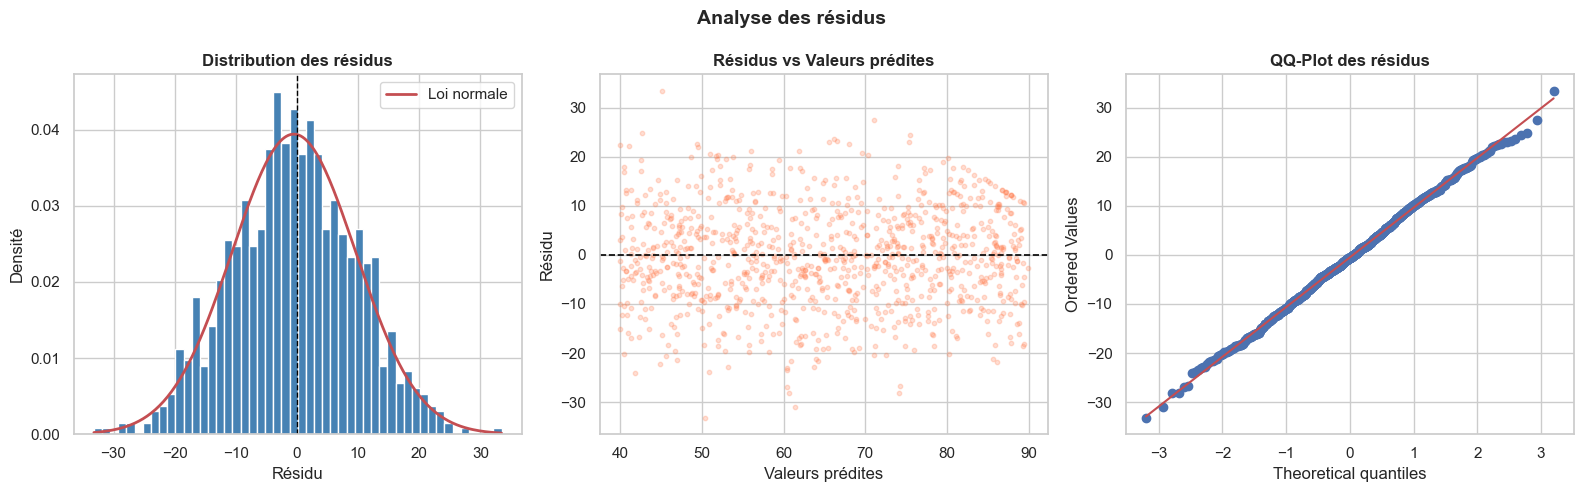

In [18]:
from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Graphique 1 : Distribution des résidus ---
axes[0].hist(residus, bins=50, color='steelblue', edgecolor='white', density=True)
# Superposer la courbe normale théorique
mu, sigma = residus.mean(), residus.std()
x_norm = np.linspace(residus.min(), residus.max(), 200)
axes[0].plot(x_norm, stats.norm.pdf(x_norm, mu, sigma), 'r-', linewidth=2, label='Loi normale')
axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Distribution des résidus', fontweight='bold')
axes[0].set_xlabel('Résidu')
axes[0].set_ylabel('Densité')
axes[0].legend()

# --- Graphique 2 : Résidus vs Valeurs prédites ---
axes[1].scatter(y_pred, residus, alpha=0.25, s=10, color='coral')
axes[1].axhline(0, color='black', linewidth=1.2, linestyle='--')
axes[1].set_title('Résidus vs Valeurs prédites', fontweight='bold')
axes[1].set_xlabel('Valeurs prédites')
axes[1].set_ylabel('Résidu')

# --- Graphique 3 : QQ-Plot ---
stats.probplot(residus, plot=axes[2])
axes[2].set_title('QQ-Plot des résidus', fontweight='bold')

plt.suptitle('Analyse des résidus', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.2 Test de normalité de Shapiro-Wilk

**À compléter :** Appliquez le test de Shapiro-Wilk sur un échantillon des résidus et interprétez le résultat.

In [20]:
from scipy.stats import shapiro

# Shapiro-Wilk (limité à 5000 obs — on prend un échantillon de 1000)
np.random.seed(42)
echantillon_residus = np.random.choice(residus, size=1000, replace=False)

stat_W, p_value = shapiro(echantillon_residus)

print("Test de normalité de Shapiro-Wilk (n=1000)")
print(f"  Statistique W : {stat_W:.4f}")
print(f"  p-valeur      : {p_value:.4e}")
print()
if p_value < 0.05:
    print("  ❌ On rejette H₀ (α=0.05) : les résidus ne suivent pas une loi normale.")
else:
    print("  ✅ On ne rejette pas H₀ (α=0.05) : les résidus sont compatibles avec la normalité.")

Test de normalité de Shapiro-Wilk (n=1000)
  Statistique W : 0.9989
  p-valeur      : 7.9475e-01

  ✅ On ne rejette pas H₀ (α=0.05) : les résidus sont compatibles avec la normalité.


### Question 5 — Analyse des résidus

> a) Listez les **4 hypothèses** classiques d'un modèle de régression linéaire (OLS). Pour chacune, indiquez si elle semble vérifiée dans notre cas.  
> b) Que vous indique le QQ-Plot sur la normalité des résidus ? La courbe s'écarte-t-elle des quartiles théoriques ?  
> c) La résidu moyen est proche de 0. Pourquoi est-ce une propriété mathématique garantie par la méthode des moindres carrés ?

**✏️ Votre réponse :**

a) Les 4 hypothèses OLS sont : linéarité, indépendance des erreurs, homoscedasticité (variance constante des résidus), normalité des résidus. Dans notre cas, elles semblent globalement respectées, notamment la normalité (test de Shapiro-Wilk : p-valeur = 0,79).

b) Le QQ-Plot montre que les résidus suivent globalement la droite, donc la normalité est à peu près respectée, ce qui est confirmé par le test de Shapiro-Wilk.

c) Le résidu moyen est proche de 0 car c’est une propriété mathématique de la méthode des moindres carrés : la somme des résidus est toujours nulle sur l’échantillon d’apprentissage.

---
## Partie 6 — Diagnostic d'Erreurs
---

> ⚠️ Les cellules suivantes contiennent des **erreurs volontaires**. Identifiez-les, expliquez-les et corrigez-les.

###  Erreur 1 — Mauvaise dimension des features

In [22]:
# ❌ CODE BUGUÉ — Identifiez et corrigez l'erreur

X_bug = df['study_hours']           # Série pandas 1D
y_bug = df['grade']

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_bug, y_bug, test_size=0.2, random_state=42)

modele_bug = LinearRegression()
try:
    modele_bug.fit(X_train_b, y_train_b)
    print("Modèle entraîné avec succès.")
except Exception as e:
    print(f"Erreur : {type(e).__name__}")
    print(f"Message : {e}")

Erreur : ValueError
Message : Expected a 2-dimensional container but got <class 'pandas.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.


###  Question 6 — Erreur 1

> a) Quel message d'erreur obtenez-vous ? Quelle en est la cause précise ?  
> b) Proposez deux façons de corriger cette erreur.

**✏️ Votre réponse :**

a) Erreur : ValueError
Message : Expected a 2-dimensional container but got <class 'pandas.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.

La cause de cette erreur est que le modèle de régression linéaire attend une matrice 2D pour les features (même s’il n’y a qu’une seule variable explicative), mais on lui a passé une série 1D.

b) Correction 1 : Reshaper la série en DataFrame avec `X_train.values.reshape(-1, 1)`
Correction 2 : Utiliser les double crochets pour sélectionner la colonne : `X_train = df_train[['study_hours']]`

In [24]:
# ✅ CORRECTION 1 (double crochet) :

X_bug2 = df[['study_hours']]  # DataFrame 2D
y_bug2 = df['grade']
X_train_b2, X_test_b2, y_train_b2, y_test_b2 = train_test_split(X_bug2, y_bug2, test_size=0.2, random_state=42)
modele_ok = LinearRegression().fit(X_train_b2, y_train_b2)


# ✅ CORRECTION 2 (reshape) :
X_bug3 = df['study_hours'].values.reshape(-1, 1)  # passage en 2D
y_bug3 = df['grade'].values
X_train_b3, X_test_b3, y_train_b3, y_test_b3 = train_test_split(X_bug3, y_bug3, test_size=0.2, random_state=42)
modele_ok2 = LinearRegression().fit(X_train_b3, y_train_b3)

### Erreur 2 — Évaluation sur le mauvais ensemble

In [25]:
# ❌ CODE BUGUÉ — Identifiez le problème (pas d'exception, mais un résultat trompeur)

modele_v2 = LinearRegression()
modele_v2.fit(X_train, y_train)

# Prédiction et évaluation
y_pred_train = modele_v2.predict(X_train)   # ← attention ici
r2_trompeur  = r2_score(y_train, y_pred_train)

print(f"R² obtenu : {r2_trompeur:.4f}")
print("Super modèle ! 🎉")

R² obtenu : 0.6837
Super modèle ! 🎉


###  Question 7 — Erreur 2

> a) Ce code ne génère aucune exception. Pourquoi est-il quand même problématique ?  
> b) Le R² calculé ici est-il plus élevé, plus bas, ou égal au R² calculé sur le test ? Pourquoi ?  
> c) Quel est le phénomène que l'on risque de ne pas détecter avec cette approche ?

**✏️ Votre réponse :**

a) Ce code est problématique car il évalue le modèle sur les mêmes données que celles utilisées pour l'entraîner (le train). Cela donne une impression trompeuse de performance : le modèle "connaît" déjà ces données et s'y adapte parfaitement, donc les scores sont artificiellement élevés. En pratique, on veut savoir comment le modèle se comporte sur des données nouvelles, jamais vues.

b) Le R² calculé ici est presque toujours plus élevé que celui obtenu sur le test set. Sur le train, le modèle peut "coller" au mieux aux données, alors que sur le test, il doit généraliser. Un R² très élevé sur le train mais plus faible sur le test indique souvent un surapprentissage (overfitting).

c) Avec cette approche, on risque de ne pas détecter le surapprentissage (overfitting). On croit que le modèle est excellent, alors qu'il peut très mal se comporter sur de nouvelles données.

In [26]:
# ✅ CORRECTION — Évaluation correcte sur le test set :
y_pred_test = modele_v2.predict(X_test)
r2_correct = r2_score(y_test, y_pred_test)
print(f"R² correct (test set) : {r2_correct:.4f}")

R² correct (test set) : 0.6789


###  Erreur 3 — Variable non pertinente incluse

In [27]:
# ❌ CODE BUGUÉ — Ce code s'exécute, mais produit un modèle incorrect

X_bug3 = df[['student_id', 'study_hours']]  # ← student_id est inclus !
y_bug3 = df['grade']

X_train3, X_test3, y_train3, y_test3 = train_test_split(X_bug3, y_bug3, test_size=0.2, random_state=42)

modele_bug3 = LinearRegression().fit(X_train3, y_train3)
y_pred3 = modele_bug3.predict(X_test3)

print(f"Coefficients : {modele_bug3.coef_}")
print(f"R² : {r2_score(y_test3, y_pred3):.4f}")

Coefficients : [6.91660743e-05 4.99846697e+00]
R² : 0.6787


###  Question 8 — Erreur 3

> a) Regardez le coefficient associé à `student_id`. Que remarquez-vous ?  
> b) Pourquoi inclure `student_id` dans un modèle prédictif est-il une erreur conceptuelle, même si le R² reste similaire ?  
> c) En général, comment identifier les variables qui ne doivent pas être incluses dans un modèle ?

**✏️ Votre réponse :**

a) Le coefficient associé à `student_id` est quasiment nul, mais surtout, il ne veut rien dire. Ce numéro d’étudiant n’a aucun rapport avec la note, donc le modèle ne peut rien en tirer d’utile

b) Mettre `student_id` dans le modèle, c’est une erreur de logique : ce n’est qu’un identifiant, il ne porte aucune information sur la réussite ou l’échec. Même si le R² ne change pas beaucoup, ça peut rendre le modèle bizarre, fragile, et même dangereux si on change la façon de numéroter les étudiants. Le modèle pourrait croire qu’il y a un lien entre le numéro et la note, alors que c’est juste du hasard

c) Pour savoir si une variable doit être exclue, il faut se demander : "Est-ce que cette info a un vrai lien avec ce que je veux prédire ?" Si la réponse est non (comme pour un identifiant, un code technique, ou une colonne qui n’a de sens que pour l’organisation), il vaut mieux l’enlever.


---
## Partie 7 — Implémentation Manuelle (Sans sklearn)
---

### 7.1 Calcul des coefficients par la formule OLS

Les estimateurs OLS des moindres carrés ordinaires sont :

$$\beta_1 = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n}(x_i - \bar{x})^2} \qquad \beta_0 = \bar{y} - \beta_1 \cdot \bar{x}$$

**À compléter :** Implémentez ces formules manuellement et vérifiez qu'elles donnent le même résultat que sklearn.

In [28]:
# Données d'entraînement sous forme numpy
x_tr = X_train['study_hours'].values
y_tr = y_train.values

# Moyennes
x_bar = np.mean(x_tr)
y_bar = np.mean(y_tr)

# Calcul de beta_1 (formule OLS)
numerateur   = np.sum((x_tr - x_bar) * (y_tr - y_bar))
denominateur = np.sum((x_tr - x_bar) ** 2)
beta_1_manuel = numerateur / denominateur

# Calcul de beta_0
beta_0_manuel = y_bar - beta_1_manuel * x_bar

print(f"--- Calcul manuel (OLS) ---")
print(f"  β₀ = {beta_0_manuel:.6f}")
print(f"  β₁ = {beta_1_manuel:.6f}")

print(f"\n--- Calcul sklearn ---")
print(f"  β₀ = {beta_0:.6f}")
print(f"  β₁ = {beta_1:.6f}")

print(f"\n✅ Les résultats sont {'identiques' if abs(beta_0_manuel - beta_0) < 1e-6 else 'différents'} !")

--- Calcul manuel (OLS) ---
  β₀ = 39.917849
  β₁ = 4.999141

--- Calcul sklearn ---
  β₀ = 39.917849
  β₁ = 4.999141

✅ Les résultats sont identiques !


###  Question 9 — Moindres carrés

> a) Expliquez intuitivement ce que minimise la méthode des moindres carrés ordinaires (OLS).  
> b) Pourquoi minimise-t-on les carrés des résidus et non leurs valeurs absolues ?  
> c) Dans quel cas les estimateurs OLS ne sont-ils plus les meilleurs estimateurs linéaires non biaisés (BLUE) ?

**✏️ Votre réponse :**

a) La méthode des moindres carrés, c’est comme chercher la droite qui passe "au plus près" de tous les points du nuage. Elle essaie de faire en sorte que, globalement, les prédictions du modèle soient le moins éloignées possible des vraies valeurs. Et comme on élève les écarts au carré, on évite que les erreurs positives et négatives s’annulent, et on fait attention aux grosses erreurs.

b) On préfère minimiser les carrés des résidus plutôt que leurs valeurs absolues parce que c’est plus simple à calculer (les carrés sont différentiables partout, pas les valeurs absolues), et aussi parce que ça pénalise davantage les grosses erreurs. Si on utilisait la valeur absolue, le calcul serait plus compliqué et on traiterait toutes les erreurs de la même façon, petites ou grandes.

c) Les estimateurs OLS ne sont plus les meilleurs (BLUE) si les hypothèses de base ne sont pas respectées. Par exemple, si les erreurs n’ont pas une variance constante (hétéroscédasticité) ou si elles sont corrélées entre elles, alors la méthode OLS peut donner des résultats moins fiables. Dans ces cas-là, il existe d’autres méthodes (comme les moindres carrés pondérés) qui permettent d’obtenir de meilleures estimations. En résumé : OLS est top quand les hypothèses sont respectées, sinon il faut adapter la méthode.

---
##  Bonus — Pour Aller Plus Loin
---

### Bonus 1 — Intervalle de confiance sur les prédictions

**À compléter :** Pour un étudiant travaillant `h` heures, calculez l'intervalle de confiance à 95% autour de la prédiction.

In [ ]:
def intervalle_confiance(h, beta_0, beta_1, x_train, y_train, alpha=0.05):
    """
    Calcule la prédiction et l'intervalle de confiance à (1-alpha)*100% pour study_hours = h.
    """
    n = len(x_train)
    y_hat = beta_0 + beta_1 * h
    
    # Prédictions sur train pour calculer s²
    y_pred_train = beta_0 + beta_1 * x_train
    s2 = np.sum((y_train - y_pred_train)**2) / (n - 2)   # variance résiduelle
    s  = np.sqrt(s2)
    
    # Erreur standard de la prédiction
    x_bar = np.mean(x_train)
    se = s * np.sqrt(1/n + (h - x_bar)**2 / np.sum((x_train - x_bar)**2))
    
    # t critique
    t_crit = stats.t.ppf(1 - alpha/2, df=n-2)
    
    return y_hat, y_hat - t_crit*se, y_hat + t_crit*se

# Test pour 5 heures de travail
h_test = 5.0
pred, borne_inf, borne_sup = intervalle_confiance(
    h_test,
    beta_0_manuel, beta_1_manuel,
    X_train['study_hours'].values, y_train.values
)
print(f"Pour {h_test} heures de travail :")
print(f"  Prédiction         : {pred:.2f} points")
print(f"  Intervalle à 95%   : [{borne_inf:.2f} ; {borne_sup:.2f}]")

In [ ]:
# Visualisation de la bande de confiance
heures_range = np.linspace(0, 10, 300)
predictions, inf_band, sup_band = zip(*[intervalle_confiance(
    h, beta_0_manuel, beta_1_manuel,
    X_train['study_hours'].values, y_train.values
) for h in heures_range])

plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, alpha=0.2, s=10, color='steelblue', label='Données test')
plt.plot(heures_range, predictions, color='red', linewidth=2, label='Droite de régression')
plt.fill_between(heures_range, inf_band, sup_band, alpha=0.25, color='red', label="IC 95%")
plt.xlabel("study_hours", fontsize=12)
plt.ylabel("grade", fontsize=12)
plt.title("Droite de régression avec bande de confiance à 95%", fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

### Bonus 2 — Validation croisée (K-Fold)

**À compléter :** Évaluez la stabilité du modèle avec une validation croisée à 5 plis.

In [ ]:
from sklearn.model_selection import cross_val_score

# Validation croisée — 5 plis, métrique R²
scores_cv = cross_val_score(LinearRegression(), X, y, cv=5, scoring='r2')

print("Validation croisée à 5 plis (K=5)")
print(f"  R² par pli : {[f'{s:.4f}' for s in scores_cv]}")
print(f"  Moyenne    : {scores_cv.mean():.4f}")
print(f"  Écart-type : {scores_cv.std():.4f}")

# Comparer avec le R² obtenu sur le seul test set
print(f"\n  R² test set unique : {r2:.4f}")

### 🔶 Question Bonus — Validation croisée

> a) Pourquoi la validation croisée donne-t-elle une estimation plus fiable de la performance qu'un simple split train/test ?  
> b) L'écart-type des scores entre les plis est-il faible ou élevé ? Qu'est-ce que cela indique sur la stabilité du modèle ?  
> c) Dans quel(s) cas la validation croisée peut-elle être coûteuse et difficile à appliquer ?

**✏️ Votre réponse :**

a) ...

b) ...

c) ...

---

## ✅ Bilan du TP

| Partie | Compétence travaillée |
|---|---|
| 1 — Exploration | Chargement, statistiques descriptives, distributions |
| 2 — Corrélation | Coefficient de Pearson, nuage de points, causalité vs corrélation |
| 3 — Modèle | Construction, paramètres β₀ β₁, droite de régression |
| 4 — Évaluation | MSE, RMSE, MAE, R², graphique réel vs prédit |
| 5 — Résidus | Distribution, QQ-Plot, test de Shapiro-Wilk, hypothèses OLS |
| 6 — Erreurs | Dimension 1D, évaluation sur le train, variable inutile |
| 7 — Implémentation | Formules OLS manuelles, vérification avec sklearn |
| Bonus | Intervalles de confiance, validation croisée K-Fold |

---

*TP réalisé avec le dataset `dataset_study.csv` — 5 000 observations simulées.*